Record 0 → 3971 points


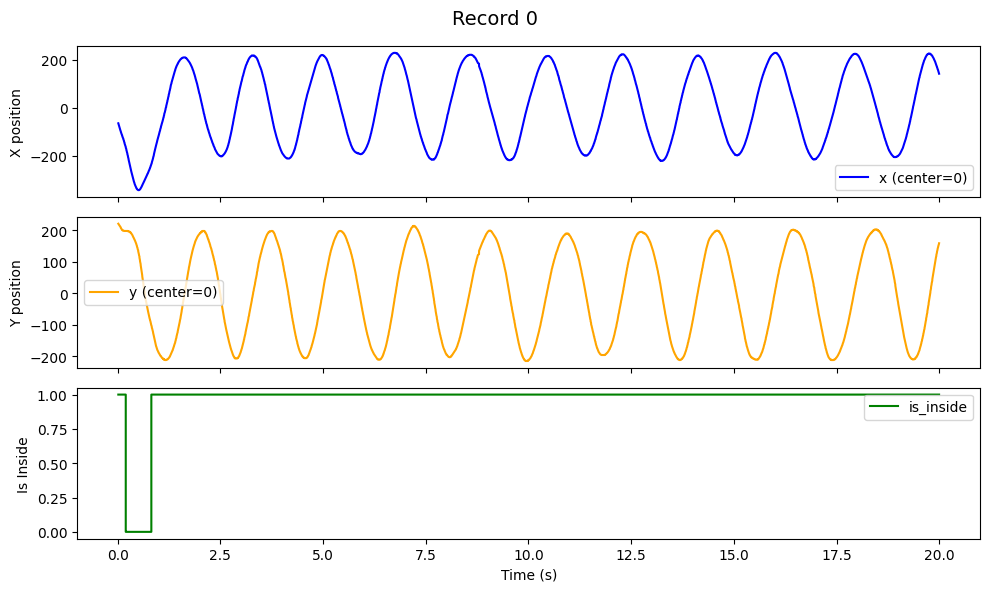

Record 1 → 3898 points


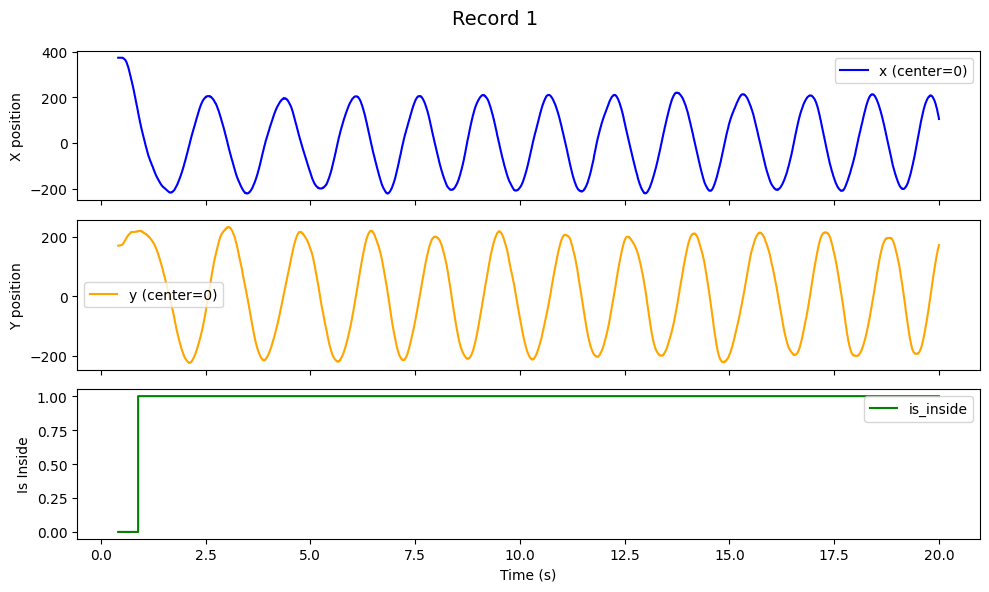

Record 2 → 3898 points


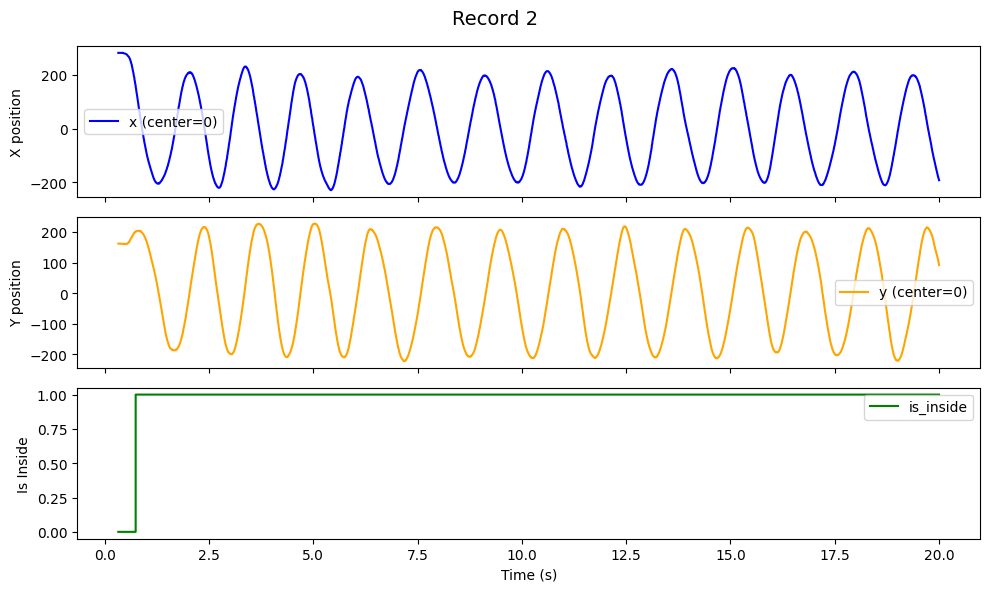

Record 3 → 3884 points


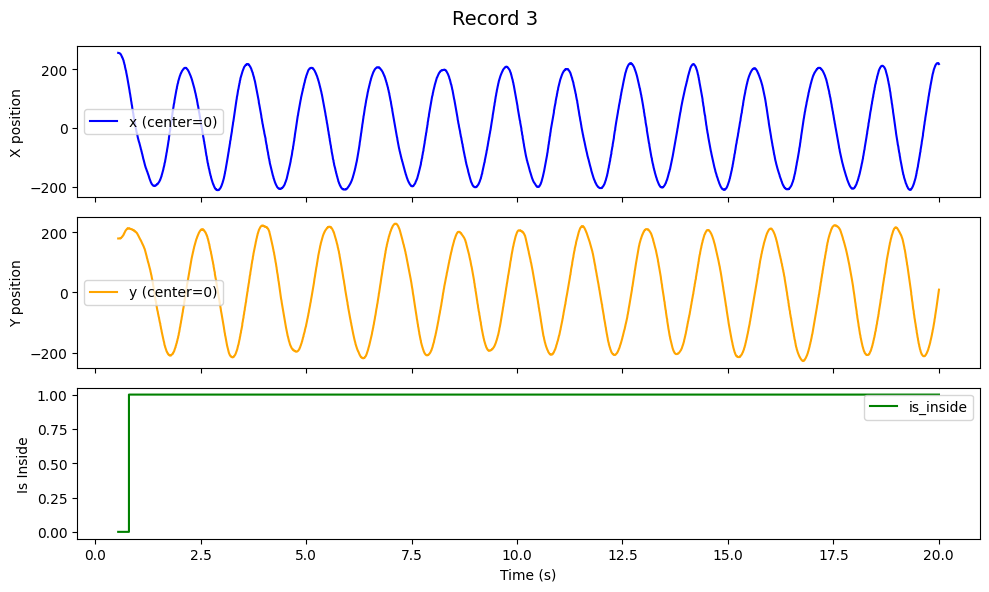

Record 4 → 3936 points


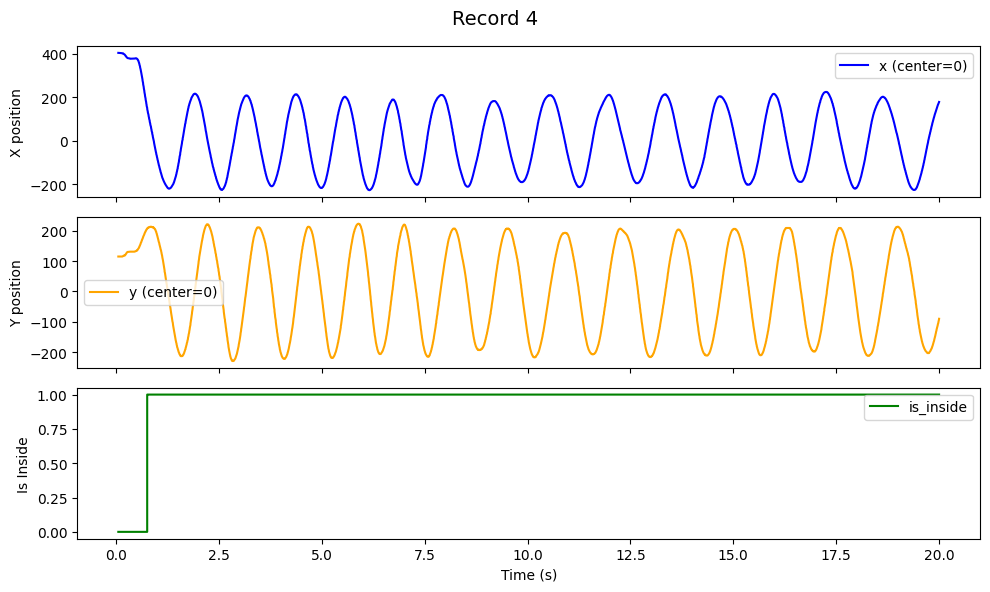

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO


# 1. Code Denis.Mottet
def read_markers(fname):
    markers_dict = {
        "time_stamp": np.array([], dtype=float),
        "label": np.array([], dtype=str),
        "fname": fname,
    }

    def add_marker(time_stamp, label):
        markers_dict["time_stamp"] = np.append(markers_dict["time_stamp"], time_stamp)
        markers_dict["label"] = np.append(markers_dict["label"], label)

    def add_multiline_marker(multiline_time_stamp, multiline_label):
        if multiline_label.endswith("\n"):
            multiline_label = multiline_label[:-1]
        add_marker(multiline_time_stamp, multiline_label)

    with open(fname, "r") as f:
        for line in f:
            if line.strip() == "":
                break

        multiline_mode = False
        multiline_label = ""
        multiline_time_stamp = np.nan

        for line in f:
            if multiline_mode:
                if line.strip() == "":
                    add_multiline_marker(multiline_time_stamp, multiline_label)
                    multiline_mode = False
                else:
                    multiline_label += line
                continue

            items = line.strip().split(",")
            time_stamp = float(items[1])
            label = items[2]
            if label == "":
                multiline_time_stamp = time_stamp
                multiline_label = ""
                multiline_mode = True
            else:
                add_marker(time_stamp, label)

        if multiline_mode:
            add_multiline_marker(multiline_time_stamp, multiline_label)

    return markers_dict

# -----------------------------
# 2. Lecture des données CSV
# -----------------------------
fname_csv = "data/001MoDe_R1.csv"
fname_marker = "data/001MoDe_R1.marker.csv"

def is_numeric_line(line):
    try:
        [float(x) for x in line.strip().split(",")]
        return True
    except:
        return False

with open(fname_csv, "r") as f:
    rows = [line for line in f if is_numeric_line(line)]

data = np.loadtxt(StringIO("".join(rows)), delimiter=",")

time_ms = data[:, 0]
x = data[:, 1]
y = data[:, 2]

# -----------------------------
# 3. Lecture des markers pour trouver le premier DoRecord
# -----------------------------
markers = read_markers(fname_marker)
do_record_times = markers["time_stamp"][np.char.startswith(markers["label"], "DoCycleChange:DoRecord")]
t0 = do_record_times[0]

# Temps relatif en secondes
time = (time_ms - t0) / 1000.0

# -----------------------------
# 4. Paramètres de la tâche
# -----------------------------
centerX, centerY = 552.0, 330.0
taskRadius, taskTolerance = 209.5, 47.0

# Recentrer le repère : centre du cercle = (0,0)
x = x - centerX
y = y - centerY

# Variable binaire "is_inside"
dist = np.sqrt(x**2 + y**2)
is_inside = dist <= (taskRadius + taskTolerance)

# -----------------------------
# 5. Intervalles des records (en secondes relatives)
# -----------------------------
record_intervals = [
    (0.004, 20.007),
    (40.011, 60.022),
    (80.043, 100.057),
    (120.061, 140.075),
    (160.090, 180.104)
]

# -----------------------------
# 6. Tracer les graphes pour chaque record
# -----------------------------
for i, (start, end) in enumerate(record_intervals):
    mask = (time >= start) & (time <= end)
    t = time[mask] - start
    x_rec = x[mask]
    y_rec = y[mask]
    inside_rec = is_inside[mask].astype(int)

    print(f"Record {i} → {mask.sum()} points")

    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Record {i}", fontsize=14)

    axs[0].plot(t, x_rec, 'b-', label='x (center=0)')
    axs[0].set_ylabel("X position")
    axs[0].legend()

    axs[1].plot(t, y_rec, 'orange', label='y (center=0)')
    axs[1].set_ylabel("Y position")
    axs[1].legend()

    axs[2].step(t, inside_rec, where='post', color='green', label='is_inside')
    axs[2].set_ylabel("Is Inside")
    axs[2].set_xlabel("Time (s)")
    axs[2].legend()

    plt.tight_layout()
    plt.show()